# Getting familiar with LIANA

`liana` provides different statistical methods to infer `ligand-receptor` interactions from single-cell transcriptomics data omics data using prior knowledge.
In this notebook we showcase how to use liana in its most basic form with toy data.



In [1]:
import scanpy as sc
import liana as li

/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


## load example dataset

In [2]:
adata = sc.datasets.pbmc68k_reduced()

`liana` typically works with the log1p-trasformed counts matrix, in this object the normalized counts are stored in `raw`:

In [3]:
adata.raw.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 174400 stored elements and shape (700, 765)>

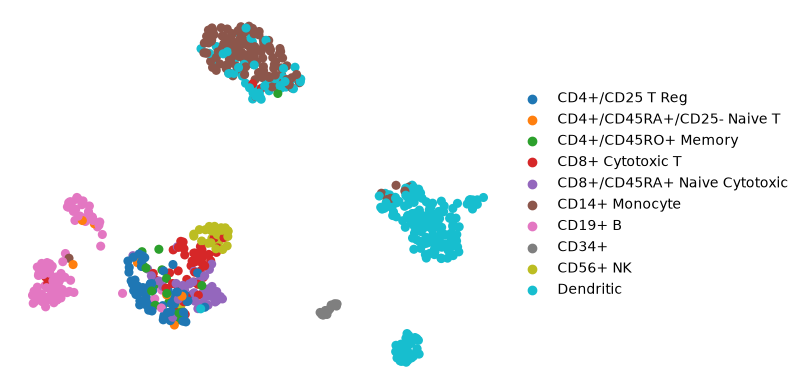

In [4]:
sc.pl.umap(adata, color='bulk_labels', title='', frameon=False)

## Methods

In [5]:
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


Each method infers relevant ligand-receptor interactions relying on different assumptions and each method returns different ligand-receptor scores, typically a pair per method. One score corresponding to
the `magnitude` (strength) of interaction and the other reflecting how `specificity` of a given interaction to a pair cell identities.

## Resources

In [6]:
li.rs.show_resources()

['baccin2019',
 'cellcall',
 'cellchatdb',
 'cellinker',
 'cellphonedb',
 'celltalkdb',
 'connectomedb2020',
 'consensus',
 'embrace',
 'guide2pharma',
 'hpmr',
 'icellnet',
 'italk',
 'kirouac2010',
 'lrdb',
 'mouseconsensus',
 'ramilowski2015']

By default, liana uses the consensus resource, which is composed by multiple expert-curated ligand-receptor resources, including CellPhoneDB, CellChat, ICELLNET, connectomeDB2020, and CellTalkDB.

In [7]:
from liana.mt import cellchat
?cellchat.__call__

## combine the scores of multiple methods

In [8]:
from liana.mt import rank_aggregate

In [9]:
rank_aggregate.describe()

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


In [10]:
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

## run cellphonedb

In [11]:
cellphonedb(adata,
            groupby='bulk_labels', 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='consensus',
            expr_prop=0.1,
            use_raw=True, verbose=True, key_added='cpdb_res')

Using resource `consensus`.


Using `.raw`!


0.94 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 700 samples and 43 features


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:00<00:00, 39222.20it/s]

In [12]:
# by default, liana's output is saved in place:
adata.uns['cpdb_res'].head()

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
482,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.612842,0.421053,Dendritic,CD4+/CD45RO+ Memory,2.575263,0.0
321,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.596125,0.500000,Dendritic,CD4+/CD45RA+/CD25- Naive T,2.566905,0.0
989,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.483977,0.302326,Dendritic,CD14+ Monocyte,2.510830,0.0
651,HLA-DRA,HLA-DRA,4.537684,0.995833,LAG3,LAG3,0.399500,0.240741,Dendritic,CD8+ Cytotoxic T,2.468592,0.0
1392,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.373671,0.270833,Dendritic,Dendritic,2.455678,0.0


### Visualization

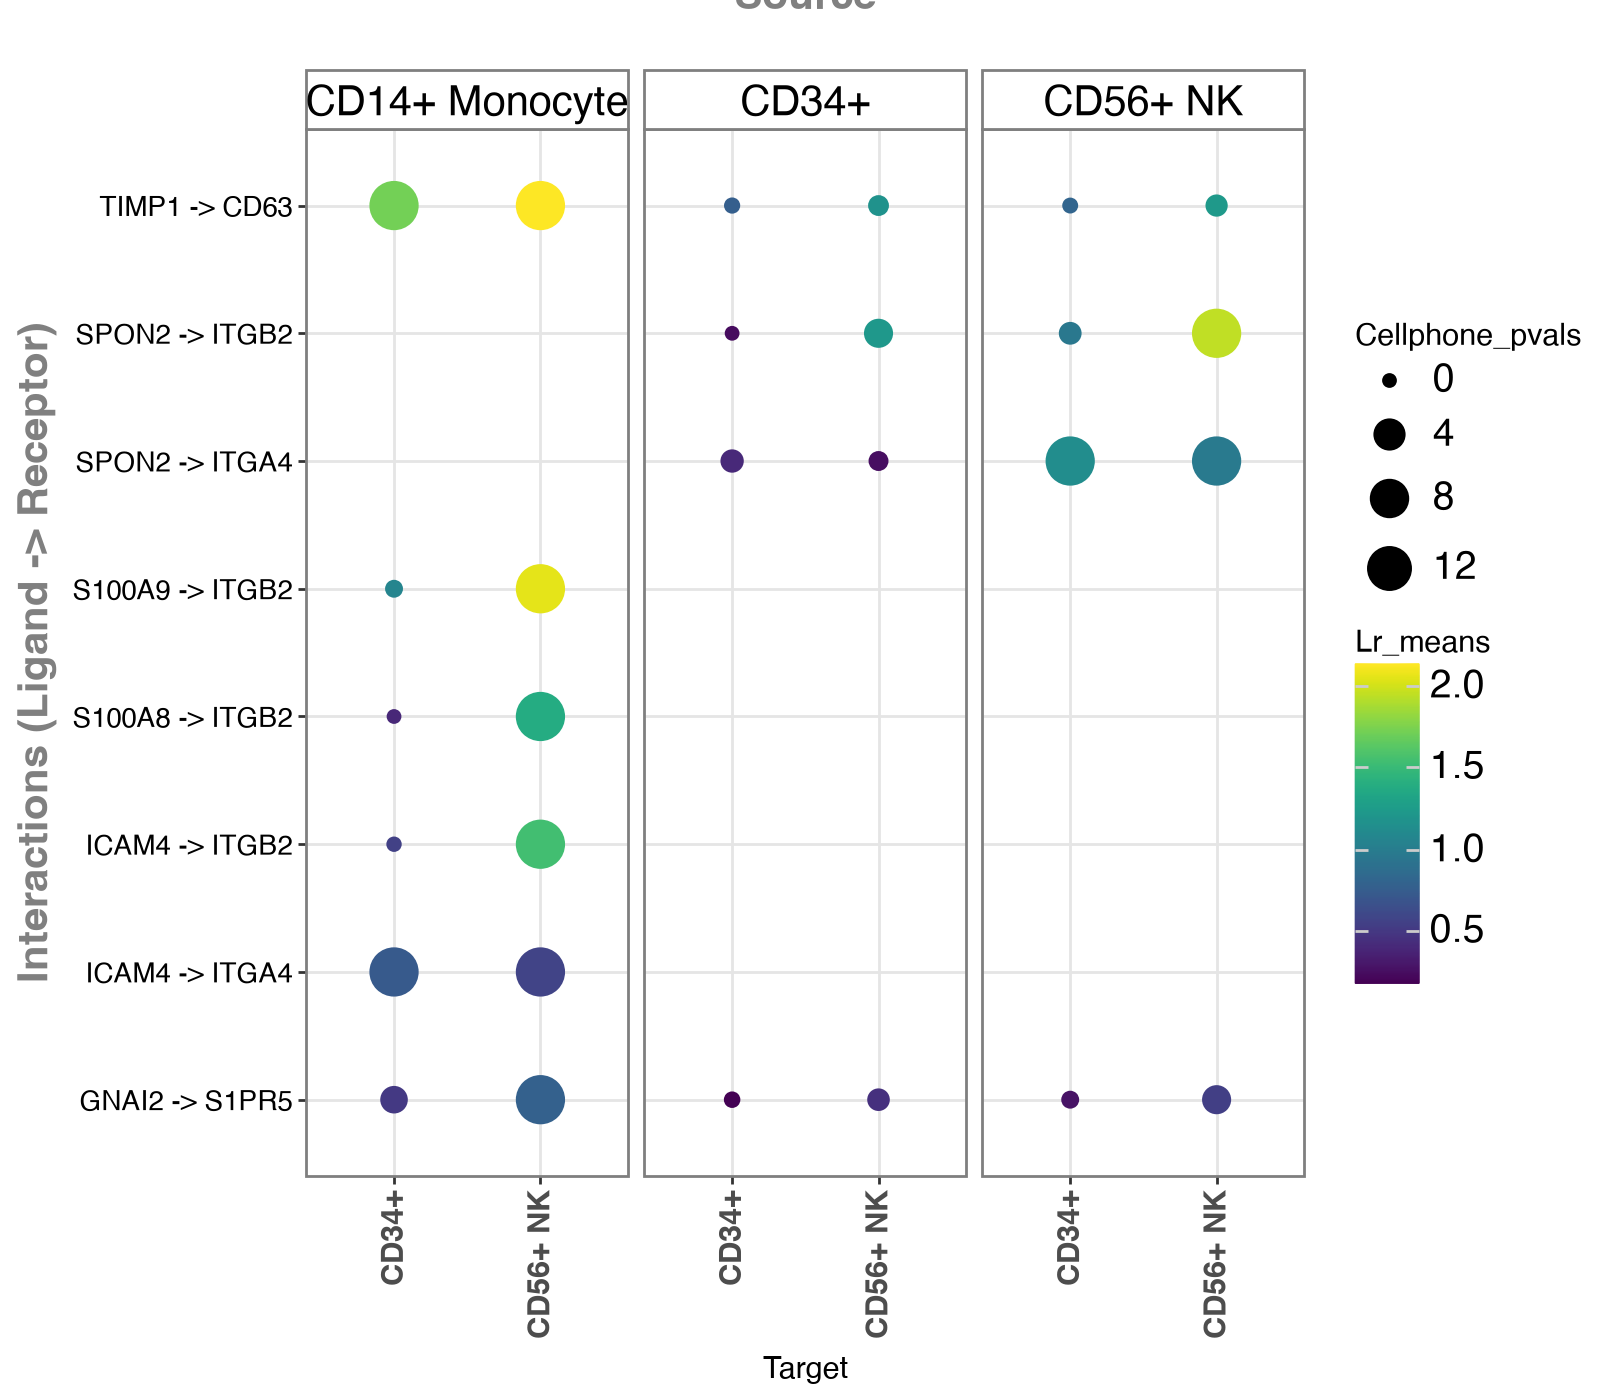

In [13]:
li.pl.dotplot(adata = adata, 
              colour='lr_means',
              size='cellphone_pvals',
              inverse_size=True, # we inverse sign since we want small p-values to have large sizes
              source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
              target_labels=['CD34+', 'CD56+ NK'],
              figure_size=(8, 7),
              # finally, since cpdbv2 suggests using a filter to FPs
              # we filter the pvals column to <= 0.05
              filter_fn=lambda x: x['cellphone_pvals'] <= 0.05,
              uns_key='cpdb_res' # uns_key to use, default is 'liana_res' 
             )

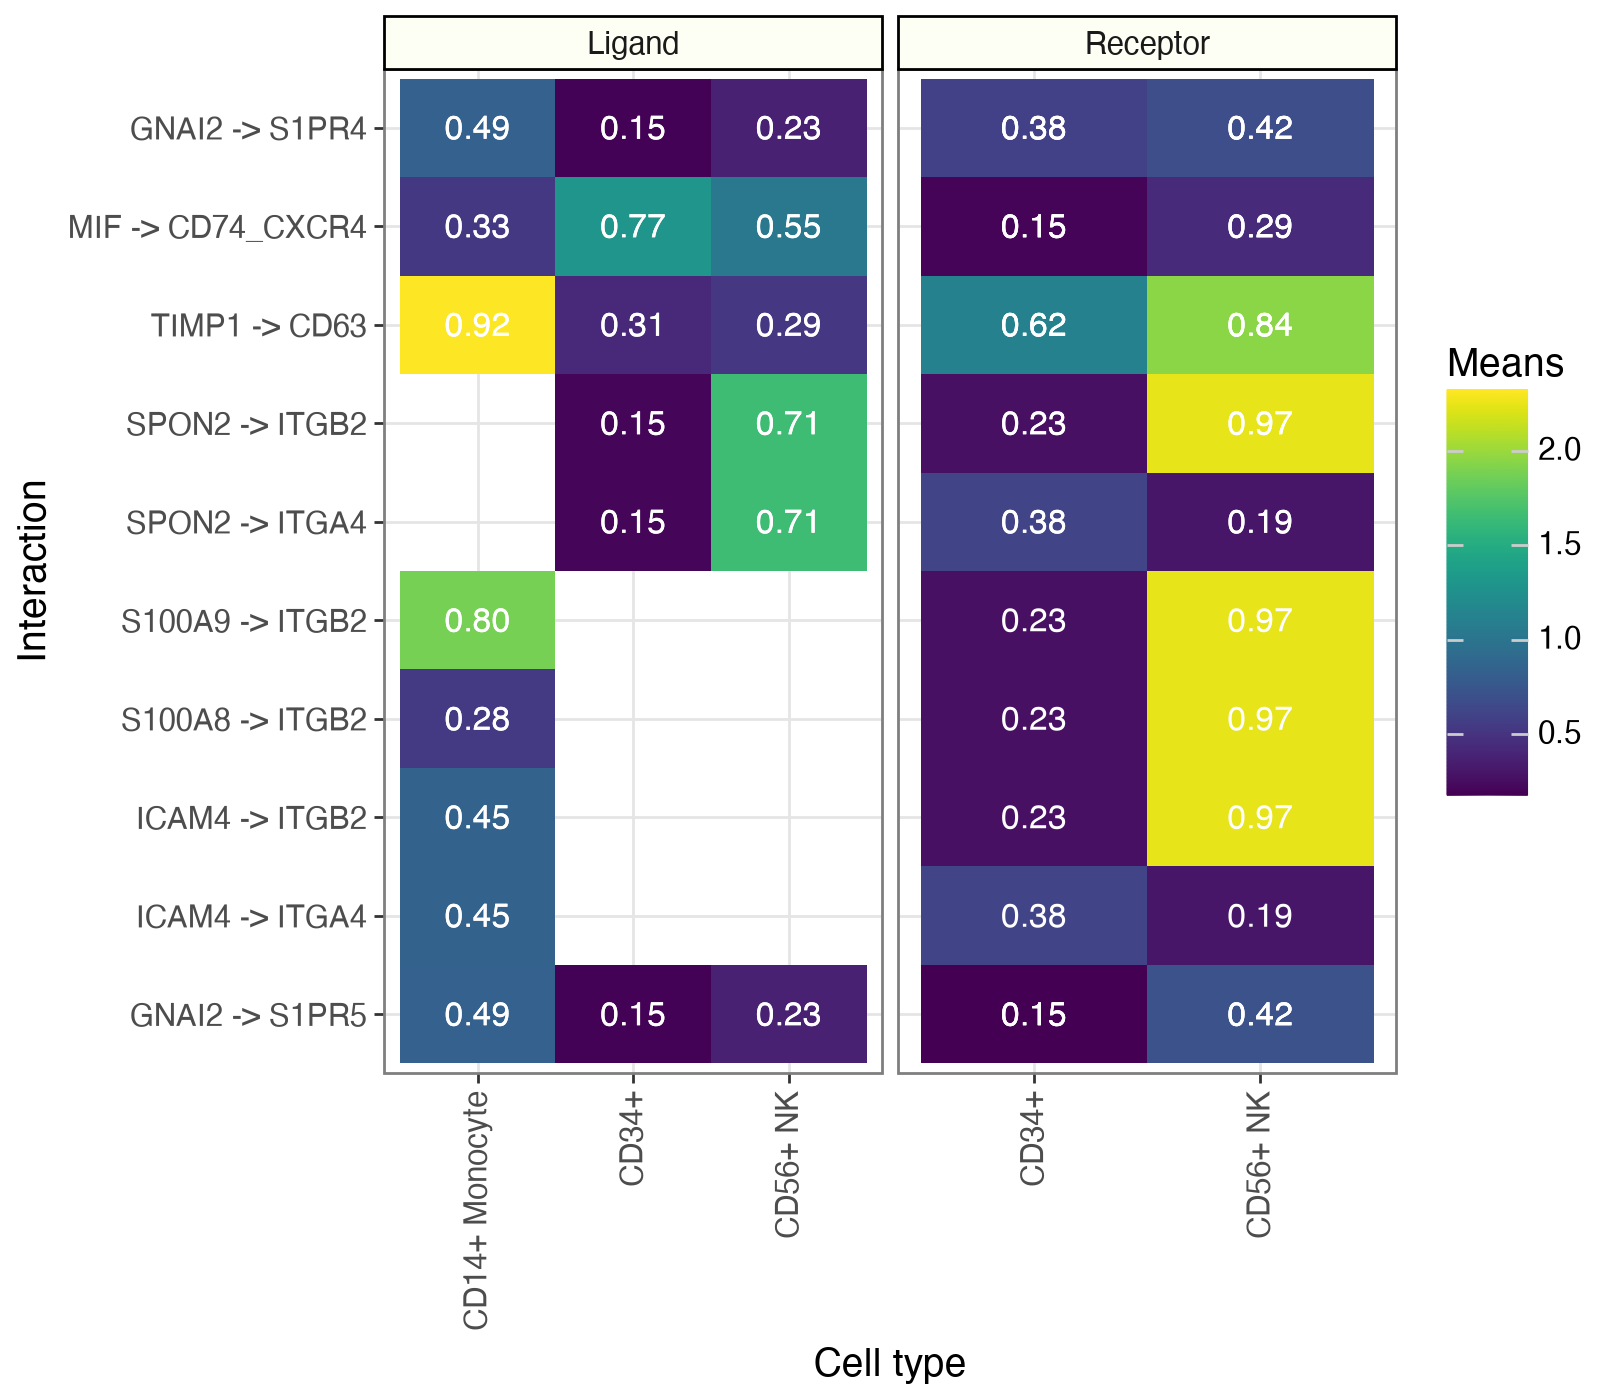

In [14]:
my_plot = li.pl.tileplot(adata = adata, 
                         # NOTE: fill & label need to exist for both
                         # ligand_ and receptor_ columns
                         fill='means',
                         label='props',
                         label_fn=lambda x: f'{x:.2f}',
                         top_n=10, 
                         orderby='cellphone_pvals',
                         orderby_ascending=True,
                         source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
                         target_labels=['CD34+', 'CD56+ NK'],
                         uns_key='cpdb_res', # NOTE: default is 'liana_res'
                         source_title='Ligand',
                         target_title='Receptor',
                         figure_size=(8, 7)
                         )
my_plot

## Ranking and aggregating

In [15]:
# Run rank_aggregate
li.mt.rank_aggregate(adata, 
                     groupby='bulk_labels',
                     resource_name='consensus',
                     expr_prop=0.1,
                     use_raw=True, verbose=True)


Using resource `consensus`.


Using `.raw`!


0.94 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 700 samples and 43 features


/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:494: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:498: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:501: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)


Assuming that counts were `natural` log-normalized!


Running CellPhoneDB


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:00<00:00, 48241.44it/s]

Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [16]:
?li.mt.rank_aggregate

In [17]:
adata.uns['liana_res'].head()

,source,target,ligand_complex,receptor_complex,ligand,receptor,ligand_means,receptor_means,ligand_props,receptor_props,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
1209,Dendritic,CD4+/CD45RO+ Memory,HLA-DRA,CD4,HLA-DRA,CD4,4.537684,0.612842,0.995833,0.421053,2.575263,0.0,2.780884,0.723815,1.431303,0.065077,0.736772,0.001137,0.000002
1188,Dendritic,CD4+/CD45RA+/CD25- Naive T,HLA-DRA,CD4,HLA-DRA,CD4,4.537684,0.596125,0.995833,0.500000,2.566905,0.0,2.705027,0.709428,1.332656,0.063302,0.734081,0.001137,0.000003
1210,Dendritic,CD4+/CD45RO+ Memory,HLA-DRB1,CD4,HLA-DRB1,CD4,4.217178,0.612842,1.000000,0.421053,2.415010,0.0,2.584465,0.712731,1.331341,0.060203,0.729607,0.001137,0.000005
110,CD14+ Monocyte,CD56+ NK,TIMP1,CD63,TIMP1,CD63,2.323713,1.945774,0.922481,0.838710,2.134744,0.0,4.521421,0.966945,1.435272,0.060475,0.781134,0.001137,0.000005
1205,Dendritic,CD4+/CD45RO+ Memory,HLA-DPB1,CD4,HLA-DPB1,CD4,4.122105,0.612842,1.000000,0.421053,2.367473,0.0,2.526199,0.731297,1.447014,0.068953,0.727352,0.001137,0.000006


### Visualization

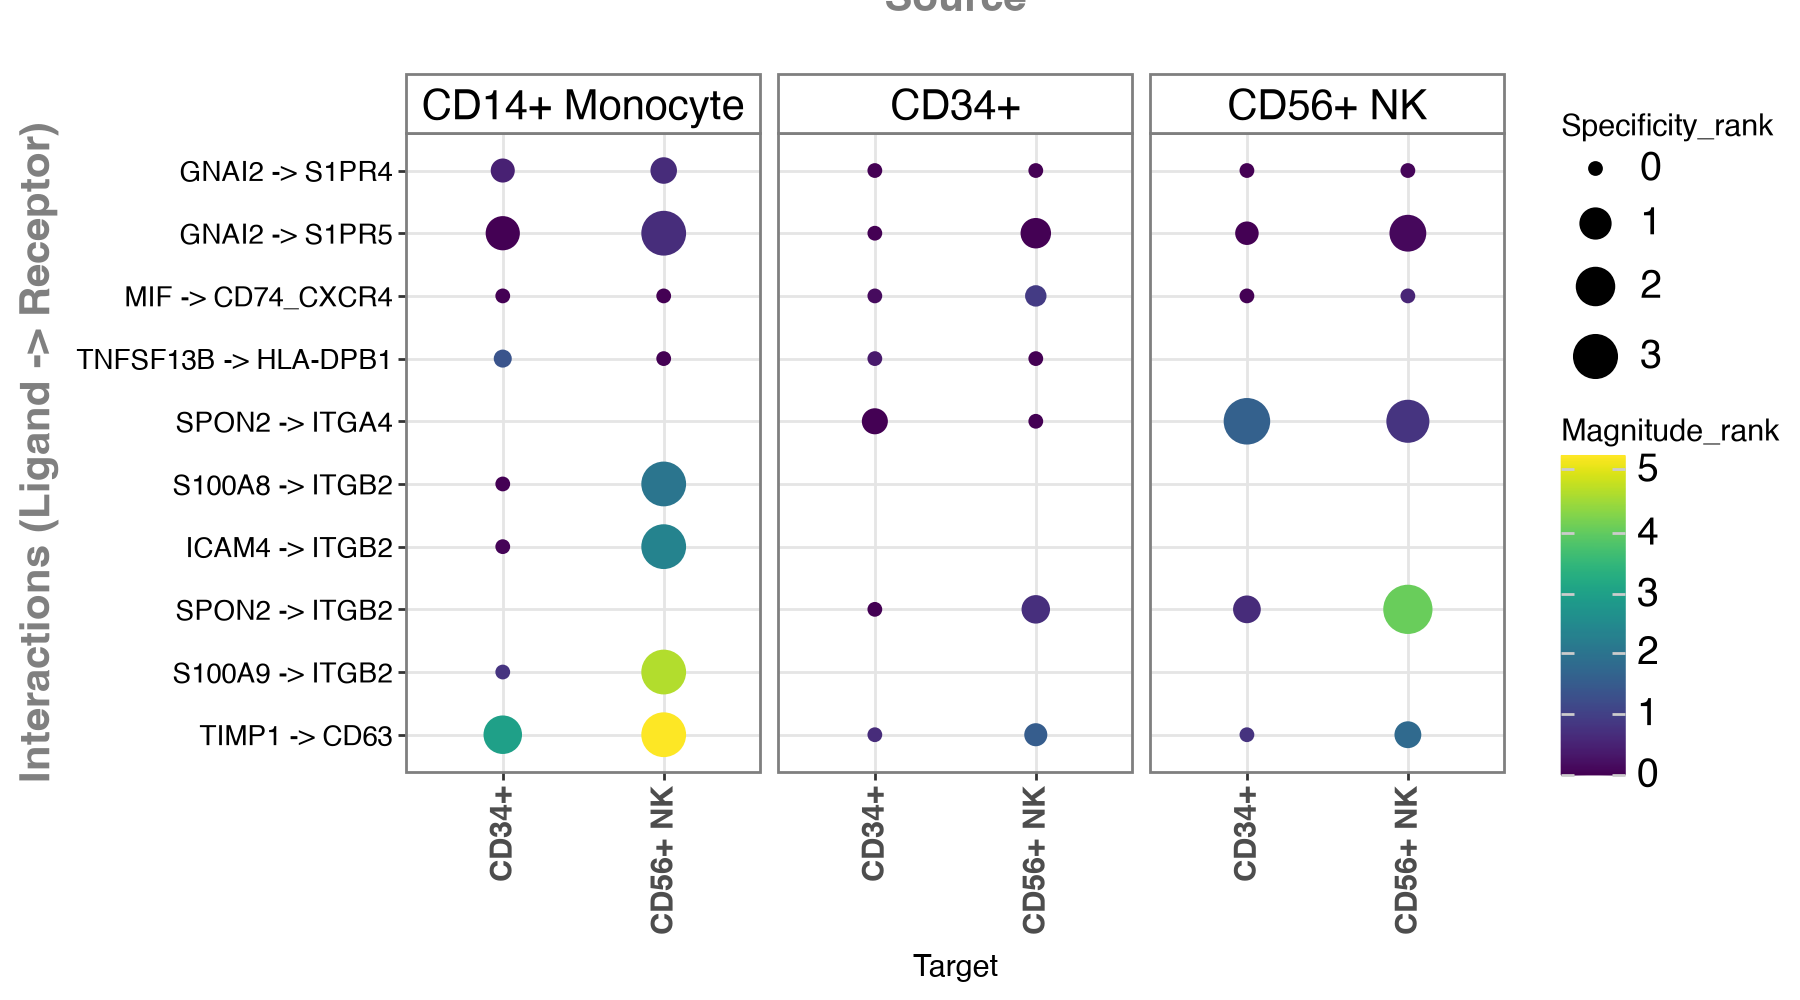

In [18]:
li.pl.dotplot(adata = adata, 
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=True,
              source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
              target_labels=['CD34+', 'CD56+ NK'],
              top_n=10, 
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(9, 5)
             )

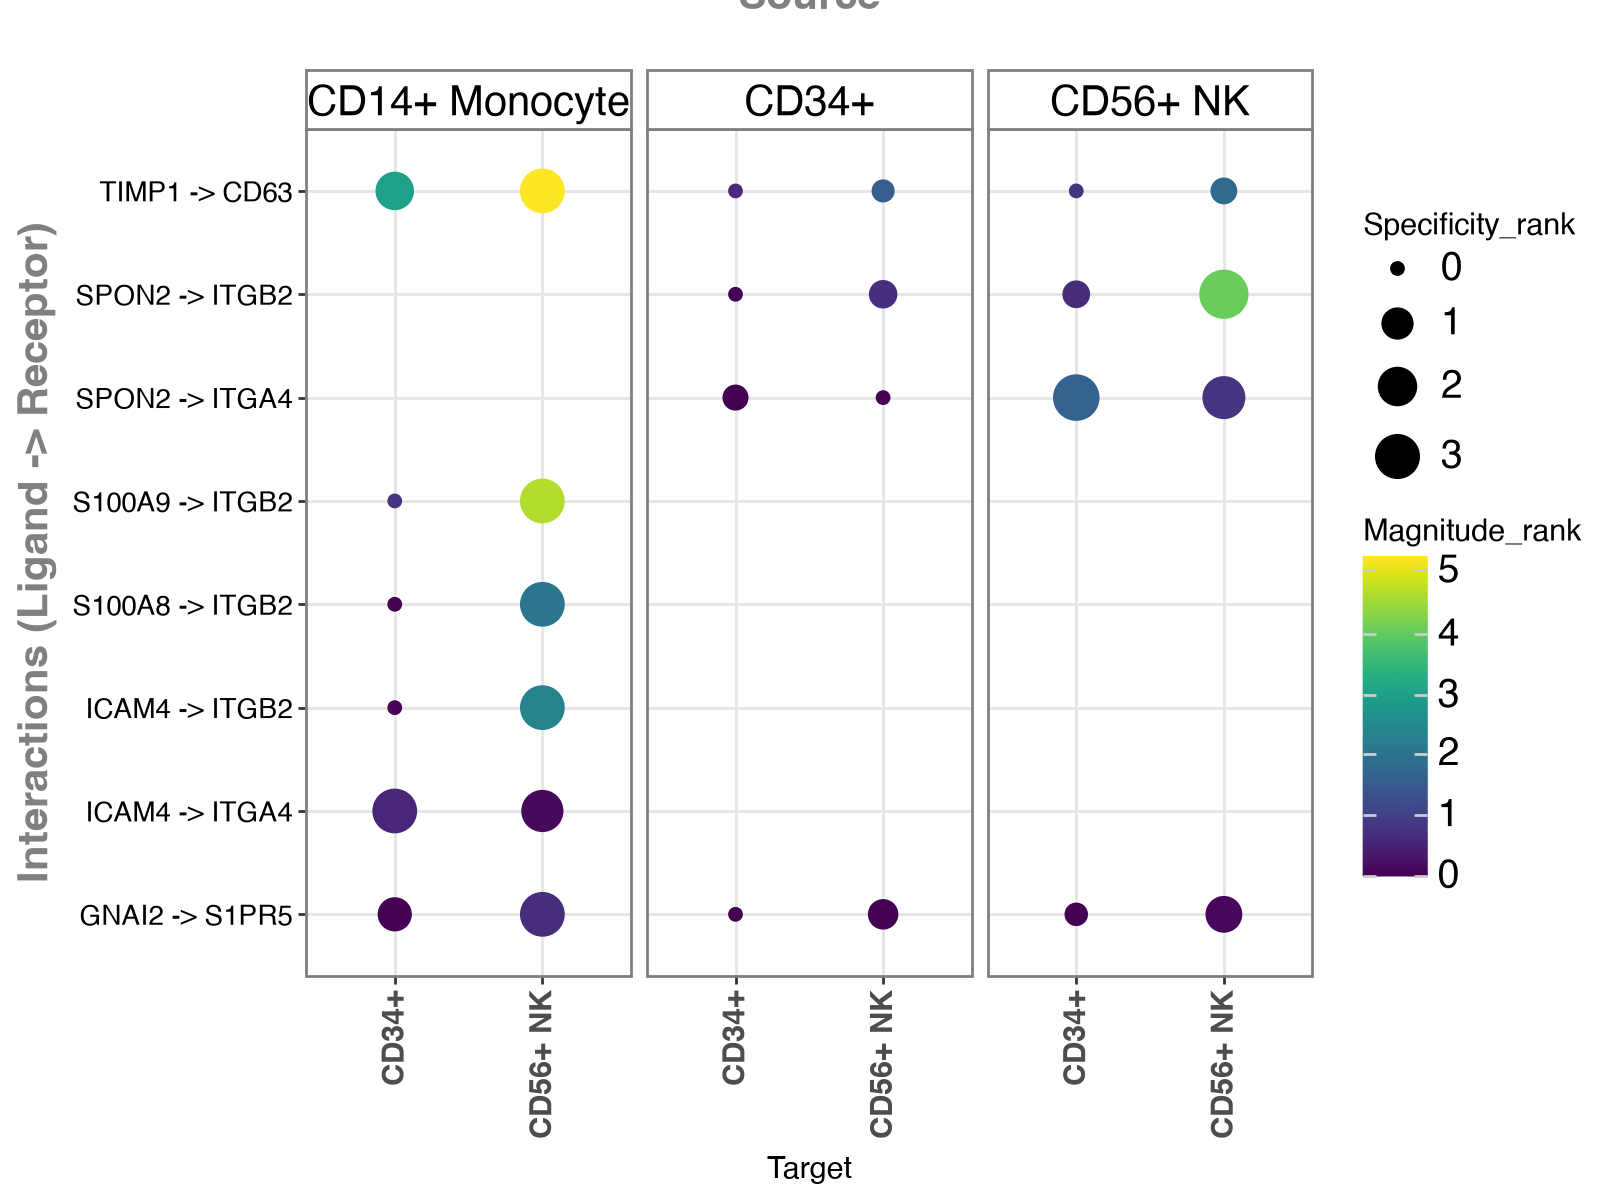

In [19]:
my_plot = li.pl.dotplot(adata = adata, 
                        colour='magnitude_rank',
                        inverse_colour=True,
                        size='specificity_rank',
                        inverse_size=True,
                        source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
                        target_labels=['CD34+', 'CD56+ NK'],
                        filter_fn=lambda x: x['specificity_rank'] <= 0.01,
                       )
my_plot

In [20]:
#Save the plot to a file
my_plot.save('dotplot.pdf')

/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: dotplot.pdf


### Customizing LIANA's Plots

In [21]:
import plotnine as p9

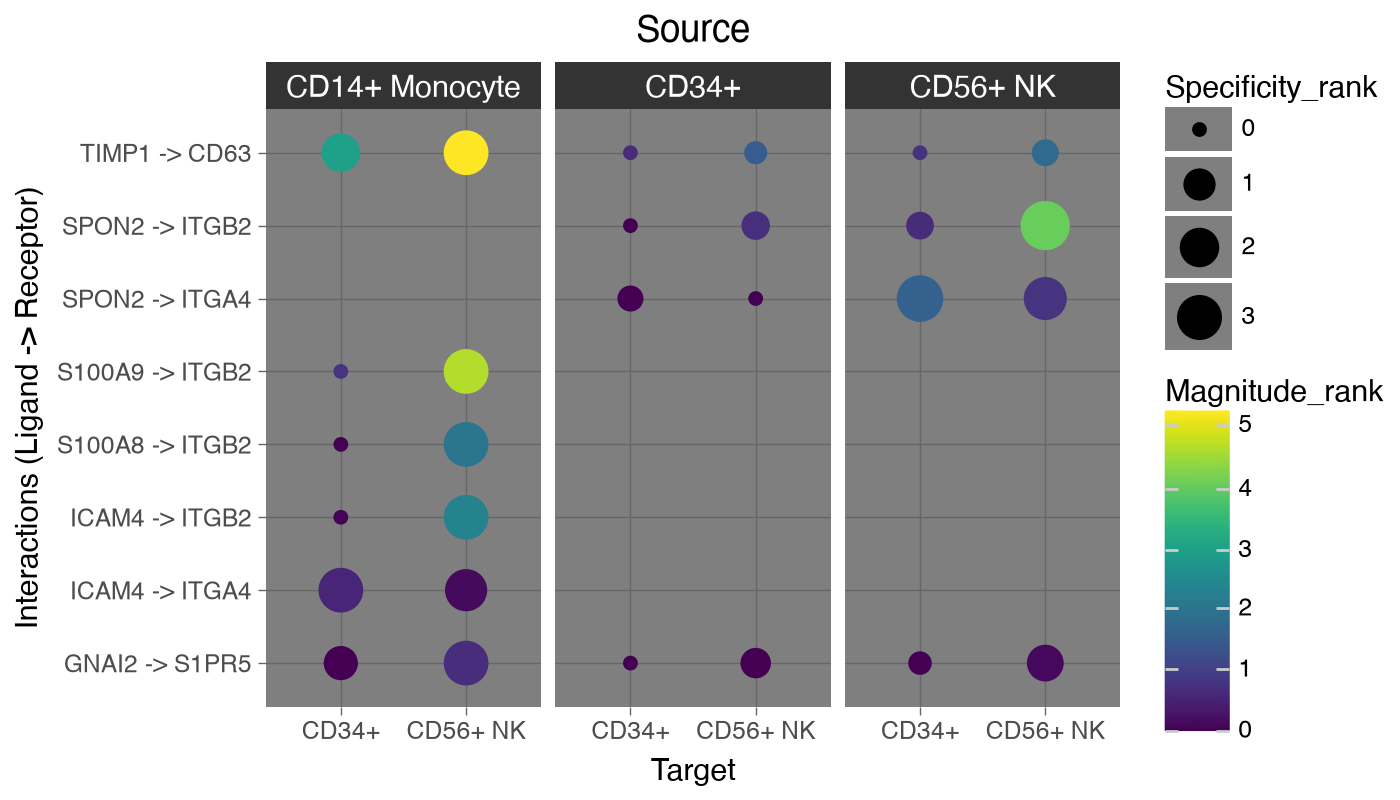

In [22]:
(my_plot +
 # change theme
 p9.theme_dark() +
 # modify theme
 p9.theme(
     # adjust facet size
     strip_text=p9.element_text(size=11),
     figure_size=(7, 4)
 )
)

<Axes: >

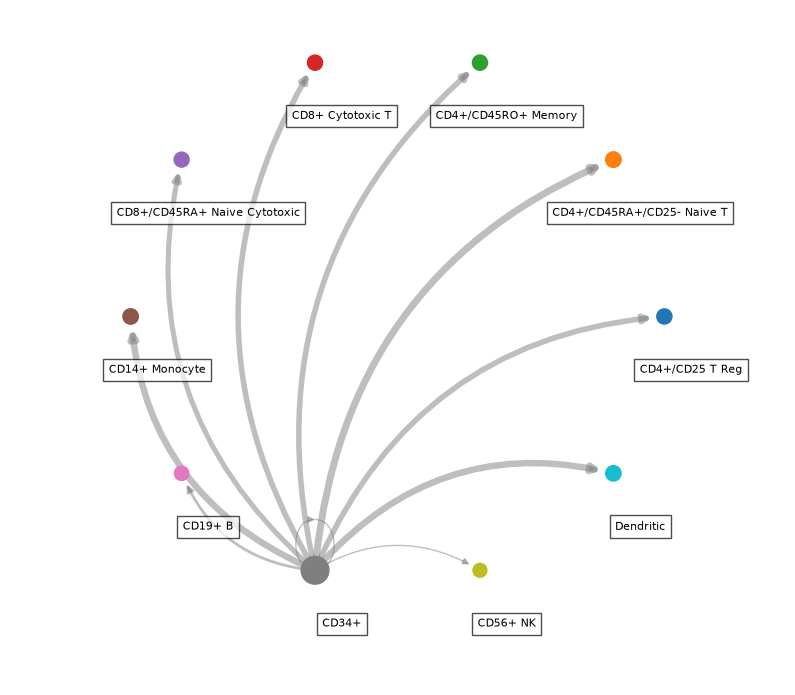

In [23]:
# Circle Plot
li.pl.circle(adata,
                  groupby='bulk_labels',
                  score_key='magnitude_rank',
                  inverse_score=True,
                  source_labels='CD34+',
                 # filter_fn=lambda x: x['specificity_rank'] <= 0.05,
                  pivot_mode='counts', # NOTE: this will simply count the interactions, 'mean' is also available
                  figure_size=(10, 10),
                  )


---

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 1 — Do the methods agree?**

Each method in `li.mt.show_methods()` scores interactions under different assumptions.
Run three or four of them individually (e.g. `cellphonedb`, `natmi`, `singlecellsignalr`,
`cellchat`), each with its own `key_added`, and compare their **top 20 interactions by
magnitude**.

Tip: every method knows its own magnitude column and sort order —
`cellphonedb.magnitude` and `cellphonedb.magnitude_ascending`.

Which methods agree with each other, and which one stands out? What does that tell you
about relying on a single method?
</div>

In [24]:
# your turn
from liana.method import cellphonedb, natmi, singlecellsignalr, cellchat

methods = [cellphonedb, natmi, singlecellsignalr, cellchat]
# ... run each method with key_added=method.method_name, then collect its top 20 interactions

<details>
<summary><b>▶ Solution</b></summary>

```python
from itertools import combinations
from liana.method import cellphonedb, natmi, singlecellsignalr, cellchat

top = {}
for method in [cellphonedb, natmi, singlecellsignalr, cellchat]:
    name = method.method_name
    method(adata, groupby='bulk_labels', resource_name='consensus',
           expr_prop=0.1, use_raw=True, key_added=name)
    res = adata.uns[name]
    res = res.sort_values(method.magnitude, ascending=method.magnitude_ascending).head(20)
    top[name] = set(res['source'] + '|' + res['target'] + '|' +
                    res['ligand_complex'] + '^' + res['receptor_complex'])

for a, b in combinations(top, 2):
    print(f"{a:>17} vs {b:<17}: {len(top[a] & top[b]):>2}/20 shared")
```

NATMI and SingleCellSignalR share all 20 of their top interactions, and CellChat shares
most of them (14/20): all three are dominated by highly expressed pairs such as
`TIMP1^CD63` and `S100A9^ITGB2` from CD14+ monocytes. CellPhoneDB is the odd one out
(1–7/20): its `lr_means` magnitude favours HLA-DRA^CD4 from dendritic cells.

Methods that share assumptions agree; methods that don't, disagree — and there is no
ground truth on this data to tell you which one is "right". This is why LIANA's default
is `rank_aggregate`: a consensus across methods is more robust than any single one
(Dimitrov et al., 2022).

</details>

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 2 (advanced) — Build your own consensus**

`rank_aggregate` combines a fixed set of methods. Build your own aggregate from a
combination of methods of your choice with `li.mt.AggregateClass`, run it on `adata`, and
compare its top interactions with the default `rank_aggregate` result
(`adata.uns['liana_res']`).

Tip: see the [LIANA+ basic usage tutorial](https://liana-py.readthedocs.io/en/latest/tutorials/notebooks/basic_usage.html)
for how `AggregateClass` is set up.
</div>

In [25]:
# your turn

<details>
<summary><b>▶ Solution</b></summary>

```python
from liana.method import cellchat, logfc, connectome

# keep the default result for comparison, since the custom run also writes to 'liana_res'
default_res = adata.uns['liana_res'].copy()

my_rank_aggregate = li.mt.AggregateClass(li.mt.aggregate_meta, methods=[cellchat, logfc, connectome])
my_rank_aggregate(adata, groupby='bulk_labels', expr_prop=0.1, use_raw=True,
                  n_perms=100, key_added='my_liana_res', verbose=True)

adata.uns['my_liana_res'].head()
```

Any combination works. The result has the same `magnitude_rank` and `specificity_rank`
columns as the default, so every plot above (`dotplot`, `tileplot`, `circle`) works on it
via `uns_key='my_liana_res'`. Expect the top interactions to shift towards whatever the
chosen methods favour — as Exercise 1 showed, the choice of methods matters.

</details>

---

## From dissociated to spatial data

Everything above needs a cell-type label per cell. On spot-based spatial data (e.g. 10X
Visium) each spot is a **mixture** of several cells, so there is no single label per spot
and label-based methods like `rank_aggregate` don't apply directly. The spot track
therefore uses spatially-informed scores that work per spot without labels: local
bivariate metrics, and then MISTy. At single-cell resolution (the image track) labels are
back, and we show how to restrict label-based methods spatially.

**Next:** `spot/01_bivariate_local.ipynb`.